## Overview
This notebook implements an automated pipeline to solve the **ML-CUP25 Regression Task** using an **Ensemble of Small Models**.

## Workflow
1.  **Data Loading**: 
    - Loads `ML-CUP25-TR.csv` and splits it into **Train**, **Validation** (20%), and **Blind Test**.

2.  **Architecture Search (Optuna)**: 
    - We use **Optuna** to find the best hyperparameters for a *single* small model.
    - **Constraints**: 
        - Depth: 1 to 2 hidden layers.
        - Width: 8 to 64 neurons per layer.
    - **Goal**: Minimize MSE on the Validation Set.

3.  **Ensemble Training**: 
    - We take the *best* architecture found by Optuna.
    - We instantiate **5 independent copies** of this model (the "Ensemble").
    - Each copy is trained from scratch with different random initializations.

4.  **Final Evaluation**:
    - The ensemble's prediction is the **average** of all 5 members.
    - We report the final MSE on the Validation and Test sets.

## How to Use
1.  **Prerequisites**: Ensure `data_loader.py` and the `models/` folder are in the same directory.
2.  **Configuration**: Adjust the constants in the first code cell (e.g., `N_TRIALS`, `ENSEMBLE_SIZE`) to control runtime.
3.  **Run All**: Execute all cells in order. The Optuna search will run first, followed automatically by the ensemble training.

In [2]:
#--- IMPORTS ---
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
import matplotlib.pyplot as plt
import sys
from sklearn.decomposition import PCA

# Ensure we can import from local modules
sys.path.append(os.getcwd())

# Import your custom modules
from utils.data_loader import get_ml_cup_data, get_monk_data
from models import StandardFeedForwardNet, EnsembleModel
from models.ensemble import ModelWithHead, ReadoutAdapter
import utils.training_utils as training_utils
from utils.training_utils import evaluate_mee
from utils.project_utils import update_json, standard_plot, plot_confusion_matrix

# --- CONFIGURATION ---
N_TRIALS = 150
N_EPOCHS_SEARCH = 100
BATCH_SIZE = 256
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

print(f"Using device: {DEVICE}")

# Global Plot Settings
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'


/Users/michaelbiggeri/Desktop/Informatica/Projects/Rage_Against_ML/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Using device: mps


## Part 1: Monk

In [6]:
# --- MONK GRID SEARCH (SINGLE SPLIT) ---
MONK_DEVICE = torch.device("cpu")
from utils.data_loader import split_dataloader
import numpy as np
import matplotlib.pyplot as plt
import copy

# Common Hyperparameters 
experiments = [
    #{'id': 1, 'reg': False, 'name': 'Monk-1'},
    {'id': 2, 'reg': False, 'name': 'Monk-2'},
    #{'id': 3, 'reg': False, 'name': 'Monk-3'},
    #{'id': 3, 'reg': True, 'name': 'Monk-3-Reg'}
]

for exp in experiments:
    monk_id = exp['id']
    is_reg = exp['reg']
    task_name = exp['name']
    
    print(f"--- Analyzing {task_name} ---")
    bs = BATCH_SIZE if 'BATCH_SIZE' in globals() else 256
    
    # LOAD DATA
    train_loader_full, test_loader, input_size, output_size = get_monk_data(monk_id, bs)
    
    # SPLIT (Seed 42 for consistency with Keras)
    train_loader, val_loader = split_dataloader(train_loader_full, val_fraction=0.2, batch_size=bs, seed=42)
    
    # Model Class
    class MonkMLP(nn.Module):
        def __init__(self, input_size, hidden_units):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_size, hidden_units),
                nn.ReLU(),
                nn.Linear(hidden_units, 1),
                nn.Sigmoid()
            )
        def forward(self, x):
            return self.net(x)

    # Grid Hypers
    learning_rates = [0.01, 0.1]
    momentums = [0.9]
    hidden_units_list = [4, 8]
    weight_decays = [0.0] if not is_reg else [0.0001, 0.001]
    epochs_list = [500] 
    
    best_val_acc = 0.0
    best_config = {}
    best_history = {}
    best_model_state = None
    
    total_configs = len(learning_rates) * len(momentums) * len(hidden_units_list) * len(weight_decays) * len(epochs_list)
    curr_config = 0
    
    for lr in learning_rates:
        for mom in momentums:
            for hu in hidden_units_list:
                for wd in weight_decays:
                    for epochs in epochs_list:
                        curr_config += 1
                        
                        model = MonkMLP(input_size, hu).to(MONK_DEVICE)
                        criterion = nn.BCELoss()
                        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=mom, weight_decay=wd)
                        
                        hist = {'loss':[], 'accuracy':[], 'val_loss':[], 'val_accuracy':[]}
                        
                        # Train Loop
                        for ep in range(epochs):
                            model.train()
                            tl=0; c=0; tot=0
                            for x,y in train_loader:
                                x,y=x.to(MONK_DEVICE), y.to(MONK_DEVICE).float().unsqueeze(1)
                                optimizer.zero_grad(); out=model(x); loss=criterion(out,y)
                                loss.backward(); optimizer.step()
                                tl+=loss.item(); c+=((out>0.5).float()==y).sum().item(); tot+=y.size(0)
                            hist['loss'].append(tl/len(train_loader)); hist['accuracy'].append(c/tot)
                            
                            model.eval()
                            vl=0; c=0; tot=0
                            with torch.no_grad():
                                for x,y in val_loader:
                                    x,y=x.to(MONK_DEVICE), y.to(MONK_DEVICE).float().unsqueeze(1)
                                    out=model(x); loss=criterion(out,y); vl+=loss.item()
                                    c+=((out>0.5).float()==y).sum().item(); tot+=y.size(0)
                            hist['val_loss'].append(vl/len(val_loader)); hist['val_accuracy'].append(c/tot)
                        
                        val_acc = hist['val_accuracy'][-1]
                        
                        if val_acc > best_val_acc:
                            best_val_acc = val_acc
                            best_config = {'lr':lr, 'momentum':mom, 'hidden_units':hu, 'weight_decay':wd, 'epochs':epochs}
                            best_history = hist
                            best_model_state = copy.deepcopy(model.state_dict())
                            print(f"  New Best: {best_config}, Val Acc: {val_acc:.4f}")

    print(f"Best Config for {task_name}: {best_config}, Val Acc: {best_val_acc:.4f}")
    
    # Test Evaluation on Best Model
    model = MonkMLP(input_size, best_config['hidden_units']).to(MONK_DEVICE)
    model.load_state_dict(best_model_state)
    model.eval()
    
    # Eval on Test
    test_correct = 0; test_total = 0; test_mse_sum = 0.0
    with torch.no_grad():
        for x, y in test_loader:
             x, y = x.to(MONK_DEVICE), y.to(MONK_DEVICE).float().unsqueeze(1)
             out = model(x)
             predicted = (out > 0.5).float()
             test_correct += (predicted == y).sum().item()
             test_mse_sum += nn.MSELoss(reduction='sum')(out, y).item()
             test_total += y.size(0)
    final_test_acc = test_correct / test_total
    final_test_mse = test_mse_sum / test_total
    
    # Eval on Train
    train_mse_sum = 0.0; train_total = 0
    with torch.no_grad():
        for x, y in train_loader:
            x, y = x.to(MONK_DEVICE), y.to(MONK_DEVICE).float().unsqueeze(1)
            out = model(x)
            train_mse_sum += nn.MSELoss(reduction='sum')(out, y).item()
            train_total += y.size(0)
    final_train_mse = train_mse_sum / train_total

    print(f"Final Test Accuracy: {final_test_acc:.4f}, Test MSE: {final_test_mse:.4f}")
    print(f"Final Train MSE: {final_train_mse:.4f}")
    
    # Dummy Baseline
    dummy_val = 0.5
    try:
        if hasattr(test_loader.dataset, 'tensors'):
            y_np = test_loader.dataset.tensors[1].cpu().numpy()
            dummy_val = max(1 - y_np.mean(), y_np.mean())
        print(f"Baseline Accuracy: {dummy_val:.4f}")
    except: pass
    
    # Plot
    standard_plot(best_history, f"{task_name} Best Config", f"{task_name.lower().replace('-', '_')}_pytorch.png", 
                  baseline_value=dummy_val, baseline_label=f"Dummy Acc: {dummy_val:.4f}", 
                  test_score=final_test_acc, test_score_label="Test Acc")
        
    update_json(task_name, "PyTorch", {
        "test_accuracy": final_test_acc, 
        "test_mse": final_test_mse,
        "train_mse": final_train_mse,
        "config": best_config
    })


--- Analyzing Monk-2 ---
Parsing MONK-2 data...
  New Best: {'lr': 0.01, 'momentum': 0.9, 'hidden_units': 4, 'weight_decay': 0.0, 'epochs': 500}, Val Acc: 0.7879
  New Best: {'lr': 0.1, 'momentum': 0.9, 'hidden_units': 8, 'weight_decay': 0.0, 'epochs': 500}, Val Acc: 1.0000
Best Config for Monk-2: {'lr': 0.1, 'momentum': 0.9, 'hidden_units': 8, 'weight_decay': 0.0, 'epochs': 500}, Val Acc: 1.0000
Final Test Accuracy: 1.0000, Test MSE: 0.0000
Final Train MSE: 0.0000
Baseline Accuracy: 0.6713
Saved plot to monk_2_pytorch.png
Updated all_results.json for Task: Monk-2, Model: PyTorch


In [19]:
# --- MANUAL MONK EXPERIMENT WITH 5-FOLD CV ---
from sklearn.model_selection import KFold
import numpy as np

# Customize these hyperparameters
MANUAL_MONK_ID = 2  # 1, 2, 3
MANUAL_IS_REG = False # Set True ONLY for Monk-3-Reg
MANUAL_LR = 0.01
MANUAL_MOMENTUM = 0.9
MANUAL_HIDDEN = 4
MANUAL_WD = 0.0
MANUAL_EPOCHS = 1000
K_FOLDS = 5

# Setup
task_name_manual = f"Monk-{MANUAL_MONK_ID}" + ("-Reg" if MANUAL_IS_REG else "")
print(f"--- Running {K_FOLDS}-Fold CV for {task_name_manual} ---")

# 1. Load Data
# We get the full training set here
train_loader_full, test_loader, input_size, output_size = get_monk_data(MANUAL_MONK_ID, BATCH_SIZE)

# Access underlying tensors for K-Fold splitting
dataset_full = train_loader_full.dataset
X_full = dataset_full.tensors[0].numpy()
y_full = dataset_full.tensors[1].numpy()

# K-Fold Setup
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

# Specific storage for aggregation
all_fold_histories = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
fold_test_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_full, y_full)):
    print(f"Starting Fold {fold+1}/{K_FOLDS}...")
    
    # Create Subsets and Loaders
    train_sub = torch.utils.data.Subset(dataset_full, train_idx)
    val_sub = torch.utils.data.Subset(dataset_full, val_idx)
    
    # Force batch_size=len(dataset) for full-batch GD if desired, otherwise BATCH_SIZE
    # User requested 'smoothing', full batch helps. Let's use BATCH_SIZE from global, usually 64.
    cur_bs = BATCH_SIZE 
    
    train_loader = torch.utils.data.DataLoader(train_sub, batch_size=cur_bs, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_sub, batch_size=cur_bs, shuffle=False)
    
    # Initialize Model (fresh for each fold)
    model = MonkMLP(input_size, MANUAL_HIDDEN).to(MONK_DEVICE)
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=MANUAL_LR, momentum=MANUAL_MOMENTUM, weight_decay=MANUAL_WD)
    
    # Fold History
    fold_hist = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    
    # Best Model Track (for this fold)
    best_fold_val_acc = 0.0
    best_fold_model_state = None
    
    for epoch in range(MANUAL_EPOCHS):
        model.train()
        train_loss = 0; correct = 0; total = 0
        for x, y in train_loader:
            x, y = x.to(MONK_DEVICE), y.to(MONK_DEVICE).float().unsqueeze(1)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            predicted = (out > 0.5).float()
            correct += (predicted == y).sum().item()
            total += y.size(0)
        
        fold_hist['loss'].append(train_loss / len(train_loader))
        fold_hist['accuracy'].append(correct / total)
        
        # Validation
        model.eval()
        val_loss = 0; correct = 0; total = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(MONK_DEVICE), y.to(MONK_DEVICE).float().unsqueeze(1)
                out = model(x)
                loss = criterion(out, y)
                val_loss += loss.item()
                predicted = (out > 0.5).float()
                correct += (predicted == y).sum().item()
                total += y.size(0)
        
        val_acc = correct / total
        fold_hist['val_loss'].append(val_loss / len(val_loader))
        fold_hist['val_accuracy'].append(val_acc)
        
        if val_acc >= best_fold_val_acc:
            best_fold_val_acc = val_acc
            best_fold_model_state = copy.deepcopy(model.state_dict())

    # Store fold history
    all_fold_histories['loss'].append(fold_hist['loss'])
    all_fold_histories['accuracy'].append(fold_hist['accuracy'])
    all_fold_histories['val_loss'].append(fold_hist['val_loss'])
    all_fold_histories['val_accuracy'].append(fold_hist['val_accuracy'])
    
    # Evaluate Best Model of Fold on TEST set
    model.load_state_dict(best_fold_model_state)
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for x, y in test_loader:
             x, y = x.to(MONK_DEVICE), y.to(MONK_DEVICE).float().unsqueeze(1)
             out = model(x)
             predicted = (out > 0.5).float()
             correct += (predicted == y).sum().item()
             total += y.size(0)
    fold_test_accuracies.append(correct / total)

# --- Aggregation and Plotting ---
mean_test_acc = np.mean(fold_test_accuracies)
std_test_acc = np.std(fold_test_accuracies)
print(f"5-Fold CV Result: Test Acc = {mean_test_acc:.4f} (+/- {std_test_acc:.4f})")

# Helper to plot mean+std
def plot_kfold_history(histories, metric, title, filename):
    plt.figure(figsize=(10, 6))
    
    # Extract data (n_folds, n_epochs)
    train_data = np.array(histories[metric])
    val_data = np.array(histories[f"val_{metric}"])
    
    epochs = range(1, train_data.shape[1] + 1)
    
    # Mean and Std
    train_mean = np.mean(train_data, axis=0)
    train_std = np.std(train_data, axis=0)
    val_mean = np.mean(val_data, axis=0)
    val_std = np.std(val_data, axis=0)
    
    # Plot Training
    plt.plot(epochs, train_mean, 'b-', label=f'Training {metric.capitalize()}')
    plt.fill_between(epochs, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.15)
    
    # Plot Validation
    plt.plot(epochs, val_mean, 'r-', label=f'Validation {metric.capitalize()}')
    plt.fill_between(epochs, val_mean - val_std, val_mean + val_std, color='red', alpha=0.15) # Stronger red for visibility
    
    plt.title(f"{title} ({metric.capitalize()})")
    plt.xlabel('Epochs')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"monk_results/{filename}")
    plt.show()

# Dummy Baseline
dummy_val = 0.5
try:
    if hasattr(test_loader.dataset, 'tensors'):
        y_test_np = test_loader.dataset.tensors[1].cpu().numpy()
        dummy_val = max(1 - y_test_np.mean(), y_test_np.mean())
    elif hasattr(test_loader.dataset, 'y'):
        y_test_np = test_loader.dataset.y.numpy()
        dummy_val = max(1 - y_test_np.mean(), y_test_np.mean())
    print(f"Baseline Accuracy: {dummy_val:.4f}")
except: pass

plot_kfold_history(all_fold_histories, 'accuracy', f"{task_name_manual} 5-Fold CV", f"manual_kfold_acc_pytorch.png")
plot_kfold_history(all_fold_histories, 'loss', f"{task_name_manual} 5-Fold CV", f"manual_kfold_loss_pytorch.png")


--- Running Manual Experiment for Monk-3-Reg ---
Parsing MONK-3 data...
Training for 8000 epochs...
Best Validation Accuracy: 0.9167
Loading best model from validation for Test Evaluation...
Final Test Accuracy: 0.9745
Saved plot to manual_monk_pytorch.png


# Part 2: ML-CUP

## Grid Search vs Randomized vs Optuna Comparison\n
Before running the full randomized search, we perform a direct comparison between **Grid Search**, **Randomized search** and **Optuna**.\n
We use a expanded budget of **288 trials** for all methods.\n
\n
- **Grid Search**: Exhaustive search over the discrete grid.\n
- **Randomized & Optuna**: Continuous search within the ranges defined by the grid boundaries.\n
\n
**Search Space:**\n
- **Hidden Units**: Fixed at 16\n
- **LR**: Grid [1e-4 .. 5e-2] | Continuous Log-Uniform [1e-4, 5e-2]\n
- **Momentum**: Grid [0.5 .. 0.9] | Continuous Uniform [0.5, 0.9]\n
- **Weight Decay**: Grid [0.0 .. 1e-1] | Continuous Log-Uniform [1e-5, 1e-1]\n
- **Activation**: ['relu', 'tanh']\n

In [ ]:
# --- GRID SEARCH vs OPTUNA COMPARISON ---
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
import time
import random
from copy import deepcopy

# 1. Setup Data for Comparison
print("--- Starting Grid Search vs Optuna vs Random Search Comparison (288 Trials each) ---")
# Capture the scaler
train_loader_cmp, val_loader_cmp, _, input_size_cmp, output_size_cmp, target_scaler_cmp = get_ml_cup_data(100, validation_ratio=0.2, test_ratio=0.2, num_workers=0)

# Define Search Space
grid_space = {
    'lr': [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2],
    'momentum': [0.5, 0.7, 0.8, 0.9],
    'weight_decay': [0.0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    'activation': ['relu', 'tanh']
}
fixed_hidden_units = 16

N_EPOCHS_COMPARE = 25

def train_and_eval(params):
    # Activation
    act_fn = nn.ReLU() if params['activation'] == 'relu' else nn.Tanh()
    
    # Model
    model = nn.Sequential(
        nn.Linear(input_size_cmp, fixed_hidden_units),
        act_fn,
        nn.Linear(fixed_hidden_units, fixed_hidden_units),
        act_fn,
        nn.Linear(fixed_hidden_units, output_size_cmp)
    ).to(DEVICE)
    
    optimizer = optim.SGD(model.parameters(), lr=params['lr'], momentum=params['momentum'], weight_decay=params['weight_decay'])
    criterion = nn.MSELoss() # Train with MSE
    
    # Train
    model.train()
    for epoch in range(N_EPOCHS_COMPARE):
        for x, y in train_loader_cmp:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            
    # Eval (Calculate MEE Unscaled)
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for x, y in val_loader_cmp:
            x = x.to(DEVICE)
            out = model(x)
            all_preds.append(out.cpu())
            all_targets.append(y.cpu())
            
    preds = torch.cat(all_preds).numpy()
    targets = torch.cat(all_targets).numpy()
    
    # Inverse Scale if needed
    if target_scaler_cmp:
        preds = target_scaler_cmp.inverse_transform(preds)
        targets = target_scaler_cmp.inverse_transform(targets)
        
    # Calculate MEE
    # MEE = Mean of Euclidean Distances per sample
    errors = np.linalg.norm(preds - targets, axis=1)
    mee = np.mean(errors)
    
    return mee

# --- 2. GRID SEARCH (Discrete) ---
print("Running Grid Search (Discrete Grid)...")
grid_results = {'trial': [], 'value': [], 'lr': [], 'momentum': [], 'weight_decay': [], 'activation': []}
trial_idx = 0
start_time = time.time()

for lr in grid_space['lr']:
    for mom in grid_space['momentum']:
        for wd in grid_space['weight_decay']:
            for act in grid_space['activation']:
                trial_idx += 1
                params = {'lr': lr, 'momentum': mom, 'weight_decay': wd, 'activation': act}
                val_mee = train_and_eval(params)
                
                grid_results['trial'].append(trial_idx)
                grid_results['value'].append(val_mee)
                grid_results['lr'].append(lr)
                grid_results['momentum'].append(mom)
                grid_results['weight_decay'].append(wd)
                grid_results['activation'].append(act)
                if trial_idx % 20 == 0:
                     print(f"Grid Trial {trial_idx}/288: {params} => MEE: {val_mee:.4f}")

grid_time = time.time() - start_time

# --- 2.5. RANDOM SEARCH (Continuous) ---
print("Running Randomized Search (Continuous)...")
random_results = {'trial': [], 'value': [], 'lr': [], 'momentum': [], 'weight_decay': [], 'activation': []}
random.seed(42) # Reproducibility
start_time = time.time()

TOTAL_TRIALS = 288

for i in range(TOTAL_TRIALS):
    # Sample Continuously
    r_lr = 10 ** random.uniform(np.log10(1e-4), np.log10(5e-2))
    r_mom = random.uniform(0.5, 0.9)
    r_wd = 10 ** random.uniform(np.log10(1e-5), np.log10(1e-1))
    r_act = random.choice(grid_space['activation'])
    
    params = {'lr': r_lr, 'momentum': r_mom, 'weight_decay': r_wd, 'activation': r_act}
    val_mee = train_and_eval(params)
    
    random_results['trial'].append(i + 1)
    random_results['value'].append(val_mee)
    random_results['lr'].append(r_lr)
    random_results['momentum'].append(r_mom)
    random_results['weight_decay'].append(r_wd)
    random_results['activation'].append(r_act)
    
    if (i+1) % 20 == 0:
        print(f"Random Trial {i+1}/{TOTAL_TRIALS}: {params} => MEE: {val_mee:.4f}")

random_time = time.time() - start_time

# --- 3. OPTUNA SEARCH (Continuous) ---
print("Running Optuna Search (Continuous)...")
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'lr': trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'momentum': trial.suggest_float('momentum', 0.5, 0.9),
        'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-1, log=True),
        'activation': trial.suggest_categorical('activation', grid_space['activation'])
    }
    return train_and_eval(params)

start_time = time.time()
study_cmp = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_cmp.optimize(objective, n_trials=TOTAL_TRIALS)
optuna_time = time.time() - start_time

# Extract Optuna Results
optuna_results = {'trial': [], 'value': [], 'lr': [], 'momentum': [], 'weight_decay': [], 'activation': []}
for t in study_cmp.trials:
    optuna_results['trial'].append(t.number + 1)
    optuna_results['value'].append(t.value)
    optuna_results['lr'].append(t.params['lr'])
    optuna_results['momentum'].append(t.params['momentum'])
    optuna_results['weight_decay'].append(t.params['weight_decay'])
    optuna_results['activation'].append(t.params['activation'])

# --- 4. VISUALIZATION ---
print(f"Comparison Complete.")
print(f"Grid Time: {grid_time:.2f}s")
print(f"Random Time: {random_time:.2f}s")
print(f"Optuna Time: {optuna_time:.2f}s")

# Plot 1: Best Value over Trials
grid_best = np.minimum.accumulate(grid_results['value'])
random_best = np.minimum.accumulate(random_results['value'])
opt_best = np.minimum.accumulate(optuna_results['value'])

plt.figure(figsize=(10, 6))
plt.plot(grid_results['trial'], grid_best, label='Grid Search Best', marker='o')
plt.plot(random_results['trial'], random_best, label='Random Search Best', marker='s', linestyle='-.')
plt.plot(optuna_results['trial'], opt_best, label='Optuna Best', marker='x')
plt.title('Best MEE vs Trial Number')
plt.xlabel('Trial')
plt.ylabel('Best MEE')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: All Trials Values
plt.figure(figsize=(10, 6))
plt.scatter(grid_results['trial'], grid_results['value'], label='Grid', alpha=0.6)
plt.scatter(random_results['trial'], random_results['value'], label='Random', alpha=0.6, marker='s')
plt.scatter(optuna_results['trial'], optuna_results['value'], label='Optuna', alpha=0.6, marker='x')
plt.title('Trial MEE Distribution')
plt.xlabel('Trial')
plt.ylabel('MEE')
plt.legend()
plt.grid(True)
plt.show()

--- Starting Grid Search vs Optuna vs Random Search Comparison (288 Trials each) ---
Parsing ML-CUP data (TR only)...
Data Split: Train=300, Val=100, Internal Test=100
Applying scaling StandardScaler to Inputs...
Applying StandardScaler to Targets...
Running Grid Search (Discrete Grid)...
Grid Trial 20/288: {'lr': 0.0001, 'momentum': 0.7, 'weight_decay': 0.001, 'activation': 'tanh'} => MEE: 42.5191
Grid Trial 40/288: {'lr': 0.0001, 'momentum': 0.9, 'weight_decay': 1e-05, 'activation': 'tanh'} => MEE: 37.8713
Grid Trial 60/288: {'lr': 0.0005, 'momentum': 0.5, 'weight_decay': 0.1, 'activation': 'tanh'} => MEE: 37.4580
Grid Trial 80/288: {'lr': 0.0005, 'momentum': 0.8, 'weight_decay': 0.001, 'activation': 'tanh'} => MEE: 39.7253
Grid Trial 100/288: {'lr': 0.001, 'momentum': 0.5, 'weight_decay': 1e-05, 'activation': 'tanh'} => MEE: 36.6087


KeyboardInterrupt: 

## Optuna search for best model (cup)

In [3]:
# --- RUN OPTUNA SEARCH & ANALYZE TOP 5 MODELS ---
import sys
import optuna
import subprocess
import time
import pandas as pd
from IPython.display import display
from tqdm import tqdm  # progress bar

# 1. Run the external script in a background process
print(f"Starting Optuna Search (External Script)...")
# Get current environment and add the current directory (Project Root) to PYTHONPATH
my_env = os.environ.copy()
my_env["PYTHONPATH"] = os.getcwd()

cmd = [sys.executable, "utils/optuna_search_mlcup_nn.py", "--n_trials", str(N_TRIALS), "--epochs", str(N_EPOCHS_SEARCH)]

# Pass the modified environment to the subprocess
process = subprocess.Popen(cmd, env=my_env)

# 2. Monitor Progress Bar
db_url = "sqlite:///optuna_mlcup_nn.db"
pbar = tqdm(total=N_TRIALS, desc="Optuna Trials", unit="trial")

try:
    while process.poll() is None:  # Keep running while the subprocess is alive
        try:
            # Connect to DB securely
            temp_storage = optuna.storages.RDBStorage(url=db_url)
            
            try:
                study_temp = optuna.load_study(study_name="mlcup_search", storage=temp_storage)
                current_trials = len(study_temp.trials)
                pbar.n = current_trials
                pbar.refresh()
            except (KeyError, ValueError):
                pass
            
            # Dispose to release lock
            temp_storage.engine.dispose()
            del temp_storage
            
        except Exception:
            pass
            
        time.sleep(2)

except KeyboardInterrupt:
    print("Stopping external script...")

pbar.n = N_TRIALS 
pbar.refresh()
pbar.close()
print("External script finished.")

# 3. Access Results Safely
storage = optuna.storages.RDBStorage(url=db_url)

try:
    study = optuna.load_study(study_name="mlcup_search", storage=storage)
    df = study.trials_dataframe()
    df = df[df.state == "COMPLETE"]
    
    if not df.empty:
        top_5 = df.sort_values('value', ascending=True).head(5)
        cols_to_show = ['number', 'value'] + [c for c in df.columns if c.startswith('params_')]

        print(f"\nSearch Complete. Best Params: {study.best_params}")
        display(top_5[cols_to_show])
        best_params = study.best_params
    else:
        print("No complete trials found.")

finally:
    storage.engine.dispose()
    del storage

Starting Optuna Search (External Script)...


Optuna Trials: 100%|██████████| 150/150 [00:00<00:00, 202.04trial/s]Traceback (most recent call last):
  File "/Users/michaelbiggeri/Desktop/Informatica/Projects/Rage_Against_ML/utils/optuna_search_mlcup_nn.py", line 2, in <module>
    import torch
  File "/Users/michaelbiggeri/Desktop/Informatica/Projects/Rage_Against_ML/.venv/lib/python3.9/site-packages/torch/__init__.py", line 2232, in <module>
    import torch.nn.intrinsic
Optuna Trials: 100%|██████████| 150/150 [00:00<00:00, 201.57trial/s]  File "/Users/michaelbiggeri/Desktop/Informatica/Projects/Rage_Against_ML/.venv/lib/python3.9/site-packages/torch/nn/intrinsic/__init__.py", line 1, in <module>
    from torch.ao.nn.intrinsic import (
  File "/Users/michaelbiggeri/Desktop/Informatica/Projects/Rage_Against_ML/.venv/lib/python3.9/site-packages/torch/ao/nn/intrinsic/__init__.py", line 3, in <module>
    from .modules import *  # noqa: F403
  File "/Users/michaelbiggeri/Desktop/Informatica/Projects/Rage_Against_ML/.venv/lib/python3.

Stopping external script...
External script finished.

Search Complete. Best Params: {'scaler': 'standard', 'scale_target': True, 'gaussian_noise': 0.061871255288155694, 'hidden_size': 23, 'dropout': 0.10931516958616493, 'weight_decay': 1.1216990119294307e-06, 'activation': 'relu', 'lr': 0.0772411979336808}


,number,value,params_activation,params_dropout,params_gaussian_noise,params_hidden_size,params_lr,params_scale_target,params_scaler,params_weight_decay
142,142,158.078506,relu,0.109315,0.061871,23,0.077241,True,standard,0.000001
149,149,158.166855,relu,0.111896,0.072179,24,0.081192,True,standard,0.000002
143,143,159.699066,relu,0.107693,0.068043,24,0.059982,True,standard,0.000001
85,85,162.084564,gelu,0.161565,0.003387,23,0.085105,True,standard,0.000131
101,101,162.287628,gelu,0.123492,0.055221,22,0.068315,True,standard,0.000007


Loading best params from sqlite:///optuna_mlcup_nn.db...
Using Best Params from Optuna DB: {'scaler': 'standard', 'scale_target': True, 'gaussian_noise': 0.061871255288155694, 'hidden_size': 23, 'dropout': 0.10931516958616493, 'weight_decay': 1.1216990119294307e-06, 'activation': 'relu', 'lr': 0.0772411979336808}
Parsing ML-CUP data (TR only)...
Data Split: Train=300, Val=100, Internal Test=100
Applying scaling StandardScaler to Inputs...
Applying StandardScaler to Targets...
Applying Gaussian Noise to Training Data (std=0.061871255288155694)

Starting training on mps...
Epoch 100: Train MEE=23.3915, Val MEE=25.7816
Epoch 200: Train MEE=22.5727, Val MEE=25.2390
Epoch 300: Train MEE=21.7967, Val MEE=24.7947
Epoch 400: Train MEE=20.7114, Val MEE=24.1716
Epoch 500: Train MEE=20.1523, Val MEE=23.6773
Epoch 600: Train MEE=19.6562, Val MEE=23.3462
Epoch 700: Train MEE=19.4029, Val MEE=23.2904
Epoch 800: Train MEE=19.0301, Val MEE=23.2908
Epoch 900: Train MEE=18.5465, Val MEE=23.3538
Epoch 10

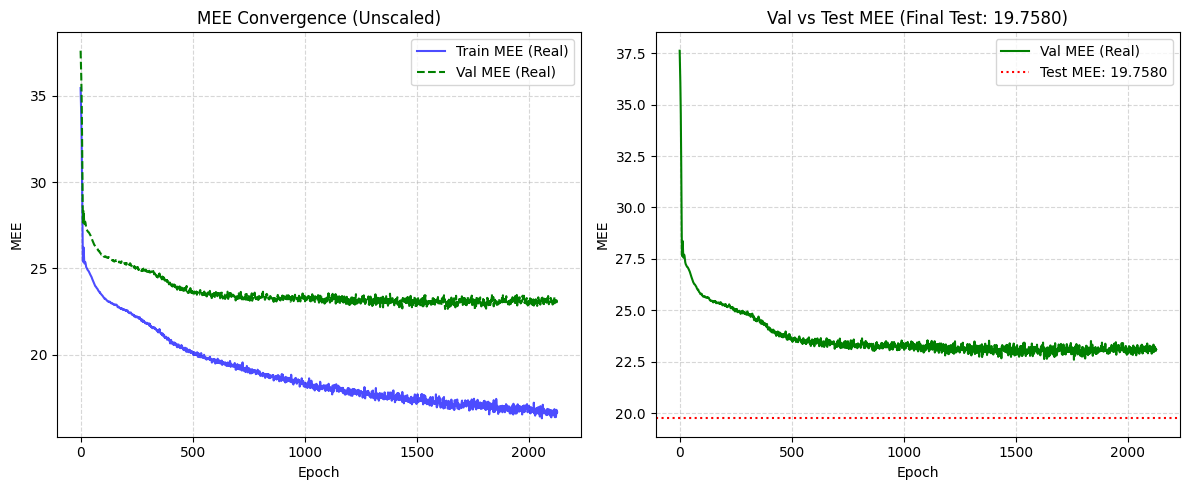

In [13]:
# --- 3. TRAINING FINAL SINGLE MODEL ---
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import optuna

# Import custom modules
from models import StandardFeedForwardNet, ModelWithHead, ReadoutAdapter
from utils.data_loader import MLCupDataset, get_ml_cup_data, GaussianNoise
import utils.training_utils as training_utils
from utils.project_utils import update_json

# --- SETTINGS ---
N_EPOCHS_FINAL = 5000
PATIENCE = 500           # Early stopping patience
MODEL_SAVE_PATH = "models/best_pytorch_mlcup.pth"

# 1. Retrieve Best Hyperparameters from DB
db_url = "sqlite:///optuna_mlcup_nn.db"
study_name = "mlcup_search"

try:
    print(f"Loading best params from {db_url}...")
    storage = optuna.storages.RDBStorage(url=db_url)
    study = optuna.load_study(study_name=study_name, storage=storage)
    params = study.best_params
    print(f"Using Best Params from Optuna DB: {params}")
except Exception as e:
    print(f"Warning: Could not load Optuna study from DB ({e}). Using default params.")
    params = {'lr': 0.01, 'momentum': 0.9, 'hidden_size': 32, 'activation': 'relu', 'scale_target': True, 'gaussian_noise': 0.0}

use_target_scaling = params.get('scale_target', False)

# 2. Load Data
train_loader, val_loader, test_loader, INPUT_SIZE, OUTPUT_SIZE, target_scaler = get_ml_cup_data(
    400, 
    validation_ratio=0.20,
    test_ratio=0.20,
    scale_target=use_target_scaling,
    num_workers=0
)

# Apply Gaussian Noise
noise_std = params.get('gaussian_noise', 0.0)
if noise_std > 0:
    print(f"Applying Gaussian Noise to Training Data (std={noise_std})")
    train_loader.dataset.transform = GaussianNoise(std=noise_std, active=True)

# Apply PCA
if 'N_COMPONENTS' in globals() and N_COMPONENTS > 0:
    print(f"Applying PCA with {N_COMPONENTS} components...")
    pca = PCA(n_components=N_COMPONENTS)
    X_train_pca = pca.fit_transform(train_loader.dataset.X.numpy())
    X_val_pca   = pca.transform(val_loader.dataset.X.numpy())
    X_test_pca  = pca.transform(test_loader.dataset.X.numpy())
    
    train_loader.dataset.X = torch.tensor(X_train_pca, dtype=torch.float32)
    val_loader.dataset.X   = torch.tensor(X_val_pca, dtype=torch.float32)
    test_loader.dataset.X  = torch.tensor(X_test_pca, dtype=torch.float32)
    INPUT_SIZE = N_COMPONENTS

# 3. Build Model
hidden_sizes = [params.get('hidden_size', 32)] * 2
base = StandardFeedForwardNet(
    input_size=INPUT_SIZE,
    hidden_sizes=hidden_sizes,
    output_size=OUTPUT_SIZE,
    activation=params.get('activation', 'relu'),
    dropout=params.get('dropout', 0.0)
)
model = ModelWithHead(base, ReadoutAdapter(OUTPUT_SIZE, OUTPUT_SIZE, 'regression')).to(DEVICE)

# 4. Optimizer
optimizer = optim.SGD(
    model.parameters(), 
    lr=params.get('lr', 0.01), 
    weight_decay=params.get('weight_decay', 0.0),
    momentum=params.get('momentum', 0.9),
    nesterov=True
)
criterion = nn.MSELoss()

# 5. Training Loop
best_val_mee = float('inf') # We track MEE for plotting/reporting preference
best_val_loss = float('inf') # We track Loss for EARLY STOPPING safely
patience_counter = 0

train_mees = []        # Unscaled Train MEE
val_mees = []          # Unscaled Val MEE
# We can still track losses for debugging but won't plot them
train_losses = []

print(f"\nStarting training on {DEVICE}...")

for epoch in range(N_EPOCHS_FINAL):
    # --- TRAIN STEP ---
    model.train()
    train_loss_accum = 0
    samples = 0
    
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        train_loss_accum += loss.item() * x.size(0)
        samples += x.size(0)
    
    avg_train_loss = train_loss_accum / samples
    train_losses.append(avg_train_loss)
    
    # --- EVALUATION STEP ---
    # 1. Calculate Train MEE (Unscaled) - Temporarily disable noise if active
    was_noisy = False
    if hasattr(train_loader.dataset, 'transform') and hasattr(train_loader.dataset.transform, 'active'):
        if train_loader.dataset.transform.active:
            train_loader.dataset.transform.active = False
            was_noisy = True
            
    train_mee = training_utils.evaluate_mee(model, train_loader, DEVICE, target_scaler=target_scaler)
    
    if was_noisy:
        train_loader.dataset.transform.active = True # Restore noise for next epoch training
        
    # 2. Calculate Val MEE (Unscaled) and Val Loss (Real for consistency)
    val_mee = training_utils.evaluate_mee(model, val_loader, DEVICE, target_scaler=target_scaler)
    val_loss_real = training_utils.evaluate(model, val_loader, criterion, DEVICE, target_scaler=target_scaler)
    
    train_mees.append(train_mee)
    val_mees.append(val_mee)
    
    # Check Early Stopping (using Real MSE or MEE - MEE is the competition metric)
    if val_loss_real < best_val_loss:
        best_val_loss = val_loss_real
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
    else:
        patience_counter += 1
        
    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}. Best Val MSE: {best_val_loss:.4f} (Last Val MEE: {val_mee:.4f})")
        break
        
    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1}: Train MEE={train_mee:.4f}, Val MEE={val_mee:.4f}")

print(f"Training finished. Best model saved to {MODEL_SAVE_PATH}")

# --- 6. FINAL EVALUATION (INTERNAL TEST) ---
print("Loading best model for evaluation...")
best_model_state = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)
model.load_state_dict(best_model_state)
model.eval()

test_mse = training_utils.evaluate(model, test_loader, criterion, DEVICE, target_scaler=target_scaler)
test_mee = training_utils.evaluate_mee(model, test_loader, DEVICE, target_scaler=target_scaler)

print("="*40)
# Force standard python floats for printing and JSON
test_mse_float = float(test_mse)
test_mee_float = float(test_mee)
best_val_loss_float = float(best_val_loss)

print(f"FINAL RESULT (Internal Test Set)")
print(f"MSE: {test_mse_float:.4f}")
print(f"MEE: {test_mee_float:.4f}")
print("="*40)

# Save Results to JSON (using clean floats)
update_json("CUP", "PyTorch", {
    "internal_test_MEE": test_mee_float,
    "internal_test_MSE": test_mse_float,
    "best_val_MSE": best_val_loss_float
})

# --- 7. PLOTTING (MEE ONLY) ---
plt.figure(figsize=(12, 5))

# Subplot 1: Train vs Val MEE (Real Scale)
plt.subplot(1, 2, 1)
plt.plot(train_mees, label='Train MEE (Real)', color='blue', alpha=0.7)
plt.plot(val_mees, label='Val MEE (Real)', color='green', linestyle='--')
plt.title("MEE Convergence (Unscaled)")
plt.xlabel("Epoch")
plt.ylabel("MEE")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Val MEE vs Test line
plt.subplot(1, 2, 2)
plt.plot(val_mees, label='Val MEE (Real)', color='green')
plt.axhline(y=test_mee, color='red', linestyle=':', label=f'Test MEE: {test_mee:.4f}')
plt.title(f"Val vs Test MEE (Final Test: {test_mee:.4f})")
plt.xlabel("Epoch")
plt.ylabel("MEE")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("cup_pytorch_single_training_plot.png")
plt.show()


Loading best model for evaluation...
FINAL RESULT (Internal Test Set)
MSE: 125.7440
MEE: 19.7580


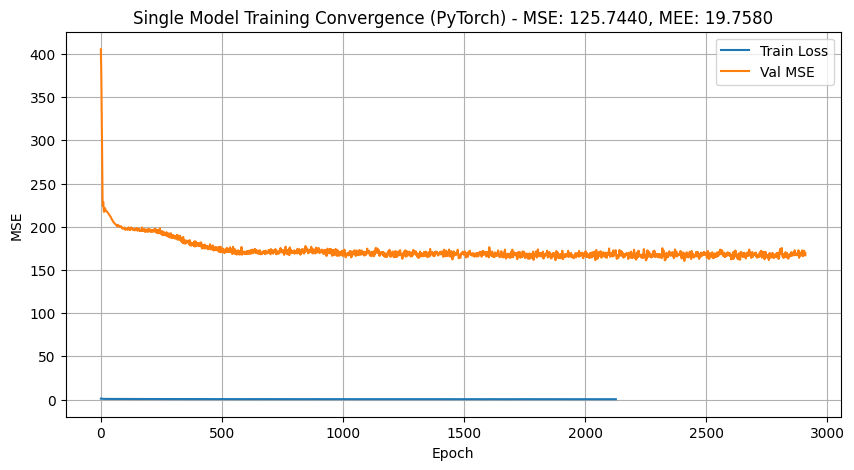

In [15]:
# --- 5. FINAL EVALUATION (INTERNAL TEST) ---
# Load Best Model
print("Loading best model for evaluation...")
best_model_state = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)
model.load_state_dict(best_model_state)
model.eval()

# Evaluate on Internal Test Set
test_mse = training_utils.evaluate(model, test_loader, criterion, DEVICE, target_scaler=target_scaler)
test_mee = training_utils.evaluate_mee(model, test_loader, DEVICE, target_scaler=target_scaler)

print("="*40)
print(f"FINAL RESULT (Internal Test Set)")
print(f"MSE: {test_mse:.4f}")
print(f"MEE: {test_mee:.4f}")
print("="*40)

'''
# Save Results to JSON
update_json("CUP", "PyTorch", {
    "internal_test_MEE": test_mee,
    "internal_test_MSE": test_mse,
    "best_val_MSE": best_val_loss
})
'''

# --- 4. PLOT TRAINING HISTORY ---
import matplotlib.pyplot as plt


# Dummy Regressor Baseline
# Robust Dummy Baseline Calculation
dummy_mse_val = None
try:
    if hasattr(train_loader.dataset, 'tensors'):
        y_tr = train_loader.dataset.tensors[1].cpu().numpy()
        y_te = test_loader.dataset.tensors[1].cpu().numpy()
        y_mean = y_tr.mean(axis=0)
        dummy_mse_val = ((y_te - y_mean)**2).mean()
        print(f"Dummy MSE: {dummy_mse_val:.4f}")
except Exception as e:
    print(f"Could not calculate dummy baseline: {e}")
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val MSE')
plt.title(f"Single Model Training Convergence (PyTorch) - MSE: {test_mse:.4f}, MEE: {test_mee:.4f}")
plt.xlabel("Epoch")
plt.ylabel("MSE")
if dummy_mse_val is not None:
    plt.axhline(y=dummy_mse_val, color='r', linestyle='--', label=f"Dummy MSE: {dummy_mse_val:.4f}")
plt.legend()
plt.grid(True)
plt.savefig("cup_pytorch_single_convergence.png")
plt.show()


In [ ]:
# --- EXTRA. TARGET DISTRIBUTION ANALYSIS (Scaled vs Unscaled) ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# 1. Recover Raw Targets from Train Loader
# We extract the Y tensor and move to numpy
y_train_scaled = train_loader.dataset.y.numpy()

# If targets were scaled in loader, we inverse transform them to get raw
if target_scaler:
    y_train_raw = target_scaler.inverse_transform(y_train_scaled)
else:
    y_train_raw = y_train_scaled

# 2. Define Scalers to Compare
scalers = {
    "Unscaled (Raw)": None,
    "StandardScaler (Z-score)": StandardScaler(),
    "MinMaxScaler (0-1)": MinMaxScaler(),
    "RobustScaler (Quantile)": RobustScaler()
}

# 3. Plot Distributions for each Target Dimension (Y1 to Y4)
num_targets = y_train_raw.shape[1]
fig, axes = plt.subplots(num_targets, len(scalers), figsize=(20, 4 * num_targets))

print("Generating Target Distribution Plots and Statistics...")

# Set pandas display options for better readability of the describe() output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.3f}'.format)

for dim_i in range(num_targets):
    target_name = f"Target_Y{dim_i+1}"
    
    # Dictionary to collect data for this target across all scalers for describe()
    comparison_data = {}

    for idx, (scaler_name, scaler_obj) in enumerate(scalers.items()):
        ax = axes[dim_i, idx]
        
        # Transform data
        if scaler_obj is None:
            data_to_plot = y_train_raw[:, dim_i]
        else:
            # Fit on full raw y and transform (we fit on all targets, then extract the specific dim)
            transformed_y = scaler_obj.fit_transform(y_train_raw)
            data_to_plot = transformed_y[:, dim_i]
            
        # Add to comparison dictionary
        comparison_data[scaler_name] = data_to_plot
        
        # Plot Histogram & KDE
        sns.histplot(data_to_plot, kde=True, ax=ax, color='skyblue', edgecolor='black')
        
        # Formatting
        ax.set_title(f"{target_name} | {scaler_name}")
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")
        
        # Add stats annotation (Mean/Std) to the plot
        mu = np.mean(data_to_plot)
        std = np.std(data_to_plot)
        ax.annotate(f"Mean: {mu:.2f}\nStd: {std:.2f}", 
                    xy=(0.05, 0.95), xycoords='axes fraction', 
                    bbox=dict(boxstyle="round", fc="white", alpha=0.8),
                    verticalalignment='top')
    
    # --- PRINT DESCRIBE() TABLE FOR CURRENT TARGET ---
    print(f"\n{'='*20} STATISTICS FOR {target_name} {'='*20}")
    df_compare = pd.DataFrame(comparison_data)
    print(df_compare.describe())
    print("-" * 80)

plt.tight_layout()
plt.show()

In [1]:
# --- EXTRA. OPTUNA RESULTS ANALYSIS & VISUALIZATION ---
import optuna
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances, plot_slice

# 1. Load the Study
db_url = "sqlite:///optuna_mlcup_nn.db"
study_name = "mlcup_search"

try:
    storage = optuna.storages.RDBStorage(url=db_url)
    study = optuna.load_study(study_name=study_name, storage=storage)
    
    print(f"Study '{study_name}' loaded successfully.")
    print(f"Total Trials: {len(study.trials)}")
    
    # 2. Display Best Trial Details
    best_trial = study.best_trial
    print("\n" + "="*40)
    print("BEST TRIAL RESULTS")
    print("="*40)
    print(f"  Value (Validation MSE): {best_trial.value:.6f}")
    print(f"  Trial Number: {best_trial.number}")
    print("  Params:")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")
    print("="*40 + "\n")

    # 3. Convert to DataFrame for Custom Analysis
    df = study.trials_dataframe()
    # Filter only complete trials
    df_success = df[df.state == "COMPLETE"].copy()
    
    # Rename columns for readability (remove 'params_' prefix)
    df_success.columns = [col.replace('params_', '') for col in df_success.columns]
    
    # Sort by value (MSE)
    top_10 = df_success.sort_values('value').head(10)
    print("Top 10 Trials:")
    display(top_10[['number', 'value'] + list(best_trial.params.keys())])

    # --- PLOTS ---
    # Set general style
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # A. Optimization History (Did we converge?)
    plt.figure(figsize=(10, 6))
    plot_optimization_history(study)
    plt.title("Optimization History (Validation MSE)", fontsize=14)
    plt.xlabel("Trial")
    plt.ylabel("MSE")
    plt.tight_layout()
    plt.show()

    # B. Hyperparameter Importance (What matters most?)
    try:
        plt.figure(figsize=(10, 6))
        plot_param_importances(study)
        plt.title("Hyperparameter Importance", fontsize=14)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not plot importance: {e}")

    # C. Slice Plots (Individual Parameter Trends)
    # We create a custom slice plot using Seaborn for better control than Optuna's default
    params_to_plot = list(best_trial.params.keys())
    n_params = len(params_to_plot)
    n_cols = 3
    n_rows = (n_params + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for i, param in enumerate(params_to_plot):
        sns.scatterplot(data=df_success, x=param, y='value', ax=axes[i], alpha=0.7, color='teal')
        
        # Highlight best value
        best_val_param = best_trial.params[param]
        axes[i].axvline(best_val_param, color='red', linestyle='--', label='Best')
        
        axes[i].set_title(f"{param} vs MSE")
        axes[i].set_ylabel("Validation MSE")
        axes[i].legend()
        
        # Log scale for learning rate and weight decay usually looks better
        if param in ['lr', 'weight_decay']:
            axes[i].set_xscale('log')

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.suptitle("Parameter Slices (Lower MSE is better)", y=1.02, fontsize=16)
    plt.show()

except Exception as e:
    print(f"Error loading study or plotting: {e}")
    print("Make sure 'optuna_mlcup_nn.db' exists and 'optuna' is installed.")

/Users/michaelbiggeri/Desktop/Informatica/Projects/Rage_Against_ML/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

# --- UTILITY: CONVERT OLD STUDIES TO CSV ---
"""
Use this cell to convert older SQLite-based Optuna studies into the new CSV format compatibility.
"""


In [ ]:
import optuna
import pandas as pd
import os
import json

def convert_study_to_csv(db_path, output_folder, study_name="mlcup_search"):
    if not os.path.exists(db_path):
        print(f"Database not found: {db_path}")
        return
        
    print(f"Loading study '{study_name}' from {db_path}...")
    try:
        storage = f"sqlite:///{db_path}"
        study = optuna.load_study(study_name=study_name, storage=storage)
        
        # Ensure output dir exists
        os.makedirs(output_folder, exist_ok=True)
        
        # 1. Save Trials CSV
        df = study.trials_dataframe()
        csv_path = os.path.join(output_folder, "optuna_results.csv")
        df.to_csv(csv_path, index=False)
        print(f"Trials saved to: {csv_path}")
        
        # 2. Save Best Params JSON
        try:
            best_params = study.best_params
            json_path = os.path.join(output_folder, "hp.json")
            with open(json_path, 'w') as f:
                json.dump(best_params, f, indent=4)
            print(f"Best Params saved to: {json_path}")
        except ValueError:
            print("Study has no completed trials. Optimization params skipped.")

    except Exception as e:
        print(f"Error converting study: {e}")

# Example Usage:
# Change 'output_folder' to save to a different directory (e.g., 'pytorch/models/optuna/experiment_v2')
# Change 'study_name' if you used a different name during search
convert_study_to_csv(
    db_path="optuna_mlcup_nn.db", 
    output_folder="pytorch/models/optuna/name", # <--- CHANGE THIS FOLDER NAME to avoid overwriting
    study_name="mlcup_search"
)


In [ ]:
# --- EXPERIMENTAL: TRAIN "BIG NETWORK" ON FULL DATA ---

# Ensure dependencies are available if running this cell alone
try:
    from torch.utils.data import TensorDataset, DataLoader
except ImportError:
    print("Importing torch modules locally...")
    import torch
    from torch.utils.data import TensorDataset, DataLoader

if 'train_loader' not in globals():
    print("Initializing Data Loader and Defaults...")
    from utils.data_loader import get_ml_cup_data
    
    BATCH_SIZE = 64
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    
    # Load FULL Training Data (including internal test set for maximum data)
    # Using test_ratio=0.2 to keep an internal eval set for MEE calculation
    train_loader, val_loader, test_loader, INPUT_SIZE, OUTPUT_SIZE, target_scaler = get_ml_cup_data(
        BATCH_SIZE, 
        validation_ratio=0.0, # No validation set for this experiment, just Train/Test split
        test_ratio=0.2,       # Keep 20% for internal evaluation
        scale_target=True,
        num_workers=0
    )
    print(f"Data Loaded: Input={INPUT_SIZE}, Output={OUTPUT_SIZE}, Device={DEVICE}")

# Configurable Hyperparameters
EXP_EPOCHS = 1500
EXP_HIDDEN_SIZE = 16
EXP_LAYERS = 2
EXP_LR = 0.01
EXP_MOMENTUM = 0.9
EXP_WEIGHT_DECAY = 0.001
EXP_ACTIVATION = 'relu'

print(f"Training Experimental Network with: Hidden={EXP_HIDDEN_SIZE}, Layers={EXP_LAYERS}, Epochs={EXP_EPOCHS}, WD={EXP_WEIGHT_DECAY}...")

# 1. Prepare Data
# Using the training set from loader
X_train_exp = train_loader.dataset.X
y_train_exp = train_loader.dataset.y

# Create dataset/loader
exp_dataset = TensorDataset(X_train_exp, y_train_exp)
exp_loader = DataLoader(exp_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 2. Build Model
# Adjust architecture based on config
hidden_sizes = [EXP_HIDDEN_SIZE] * EXP_LAYERS
base = StandardFeedForwardNet(INPUT_SIZE, hidden_sizes, OUTPUT_SIZE, EXP_ACTIVATION)
model = ModelWithHead(base, ReadoutAdapter(OUTPUT_SIZE, OUTPUT_SIZE, 'regression')).to(DEVICE)

# Optimizer
opt = torch.optim.SGD(model.parameters(), lr=EXP_LR, momentum=EXP_MOMENTUM, weight_decay=EXP_WEIGHT_DECAY, nesterov=True)
crit = torch.nn.MSELoss()

# 3. Train
train_loss_hist = []

for epoch in range(EXP_EPOCHS):
    model.train()
    batch_losses = []
    for x, y in exp_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        out = model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()
        batch_losses.append(loss.item())
    
    avg_loss = np.mean(batch_losses)
    train_loss_hist.append(avg_loss)
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{EXP_EPOCHS} | Train MSE: {avg_loss:.5f}")

# 4. Evaluate (Internal Test)
model.eval()
test_mse = training_utils.evaluate(model, test_loader, crit, DEVICE, target_scaler=target_scaler)
test_mee = training_utils.evaluate_mee(model, test_loader, DEVICE, target_scaler=target_scaler)

print("\n" + "="*30)
print(f"EXPERIMENTAL RESULTS")
print("="*30)
print(f"Final Train MSE: {train_loss_hist[-1]:.5f}")
print(f"Internal Test MSE: {test_mse:.5f}")
print(f"Internal Test MEE: {test_mee:.5f}")
print("="*30)

# 5. Plot Training Curve
plt.figure(figsize=(10, 5))
plt.plot(train_loss_hist, label='Train MSE')
plt.title("Experimental Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
